In [14]:
%pip install shap statsmodels -q
%pip install xgboost -q

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, f1_score, ConfusionMatrixDisplay
)

from xgboost import XGBClassifier 
from imblearn.over_sampling import SMOTE
from statsmodels.stats.contingency_tables import mcnemar
import shap
import os
sns.set_theme(style = "darkgrid")
BASE = r'C:\Users\adity\Desktop\Kepler-Exoplanet Project'

 Rebuild the exact Phase 4 pipeline (needed so SHAP/McNemar use the same data)

In [16]:
data_path = r'C:\Users\adity\Desktop\Kepler-Exoplanet Project\data'
df = pd.read_csv(os.path.join(data_path, 'kepler_clean.csv'))

In [17]:
TARGET = 'koi_disposition'

df_model = df[df[TARGET].isin(['CONFIRMED', 'FALSE POSITIVE'])].copy()
print(f"Rows for modeling: {len(df_model):,}")
print(df_model[TARGET].value_counts())

KEY_FEATURES = [
    'koi_period', 'koi_prad', 'koi_teq', 'koi_insol',
    'koi_model_snr', 'koi_steff', 'koi_slogg',
    'koi_srad', 'koi_score', 'koi_depth',
    'koi_duration', 'koi_impact',
    'koi_fpflag_nt', 'koi_fpflag_ss', 'koi_fpflag_co', 'koi_fpflag_ec'
]

X = df_model[KEY_FEATURES]
y_raw = df_model[TARGET]

le = LabelEncoder()
y =  le.fit_transform(y_raw)
print(f"\nLabel Encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain size: {len(X_train):,}")
print(f"Test size: {len(X_test):,}")

imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train)
X_test_imp = imputer.transform(X_test)

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_imp, y_train)
print(f"\nAfter SMOTE - class counts: {pd.Series(y_train_bal).value_counts().to_dict()}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled = scaler.transform(X_test_imp)

Rows for modeling: 6,203
koi_disposition
FALSE POSITIVE    3922
CONFIRMED         2281
Name: count, dtype: int64

Label Encoding: {'CONFIRMED': np.int64(0), 'FALSE POSITIVE': np.int64(1)}

Train size: 4,962
Test size: 1,241

After SMOTE - class counts: {1: 3137, 0: 3137}


TRAINING ALL FOUR MODELS - RF, XGBoost, GBM, SVM

In [18]:
models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=None, min_samples_split=5,
        random_state=42, n_jobs=-1
    ),
    'XGBoost' : XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        use_label_encoder=False, eval_metric='logloss', random_state=42
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42
    ),
    'SVM': SVC(
        kernel='rbf', C=1.0, probability=True, random_state=42
    )
}

results = {}
print("Model Training and Evaluation (Phase 6-4 models)")
scaler_physical = StandardScaler()
X_train_physical_scaled = scaler_physical.fit_transform(X_train_physical)
X_test_physical_scaled = scaler_physical.transform(X_test_physical)

for name, model in models.items():
    print(f"\n---{name}---")
    if name == 'SVM':
        model.fit(X_train_physical_scaled, y_train_bal)
        y_pred = model.predict(X_test_physical_scaled)
        y_prob = model.predict_proba(X_test_physical_scaled)[:, 1]
    else:
        model.fit(X_train_bal, y_train_bal)
        y_pred = model.predict(X_test_imp)
        y_prob = model.predict_proba(X_test_imp)[:, 1]
    
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    results[name] = {'model': model, 'y_pred': y_pred, 'y_prob': y_prob, 'f1': f1, 'auc': auc}

    print(f"F1 Score : {f1:.4f}")
    print(f"ROC-AUC : {auc:.4f}")
    print(classification_report(y_test, y_pred, target_names=le.classes_))

#Summary table
print("MODEL COMPARISON SUMMARY")
for name, res in sorted(results.items(), key=lambda x: x[1]['auc'], reverse=True):
    print(f"{name:<22} F1={res['f1']:.4f} AUC={res['auc']:.4f}")

Model Training and Evaluation (Phase 6-4 models)

---Random Forest---
F1 Score : 0.9943
ROC-AUC : 0.9989
                precision    recall  f1-score   support

     CONFIRMED       1.00      0.98      0.99       456
FALSE POSITIVE       0.99      1.00      0.99       785

      accuracy                           0.99      1241
     macro avg       0.99      0.99      0.99      1241
  weighted avg       0.99      0.99      0.99      1241


---XGBoost---
F1 Score : 0.9937
ROC-AUC : 0.9974
                precision    recall  f1-score   support

     CONFIRMED       1.00      0.98      0.99       456
FALSE POSITIVE       0.99      1.00      0.99       785

      accuracy                           0.99      1241
     macro avg       0.99      0.99      0.99      1241
  weighted avg       0.99      0.99      0.99      1241


---Gradient Boosting---
F1 Score : 0.9924
ROC-AUC : 0.9975
                precision    recall  f1-score   support

     CONFIRMED       0.99      0.98      0.99     

In [19]:
# Build correctly_classified / misclassified DataFrames from Random Forest predictions
rf_pred = results['Random Forest']['y_pred']

misclass_df = X_test.copy()
misclass_df['true_label'] = le.inverse_transform(y_test)
misclass_df['predicted_label'] = le.inverse_transform(rf_pred)
misclass_df['correct'] = (y_test == rf_pred)

correctly_classified = misclass_df[misclass_df['correct']]
misclassified = misclass_df[~misclass_df['correct']]

print(f"Correctly classified: {len(correctly_classified):,}")
print(f"Misclassified: {len(misclassified):,}")

Correctly classified: 1,232
Misclassified: 9


McNemar's Test - pairwise statistical significance

In [30]:
def mcnemar_test(y_true, pred_a, pred_b, name_a, name_b):
    correct_a = (pred_a == y_true)
    correct_b = (pred_b == y_true)

    both_correct = np.sum(correct_a & correct_b)
    a_only = np.sum(correct_a & ~correct_b)
    b_only = np.sum(~correct_a & correct_b)
    both_wrong = np.sum(~correct_a & ~correct_b)

    print(f"{name_a} vs {name_b}")
    print(f" Both correct: {both_correct} | {name_a} only right: {a_only} |"
          f"{name_b} only right: {b_only} | Both Wrong: {both_wrong}")

    if a_only == 0 and b_only == 0:
        print("No discordant pairs - predictions are identical. "
              f"Mcnemar's test is undefined here; treated as not significant.\n")
        return 1.0
    
    table = [[both_correct, a_only], [b_only, both_wrong]]

    use_exact = (a_only + b_only) < 25
    result = mcnemar(table, exact=use_exact, correction=not use_exact)

    print(f"McNemar Statistic: {result.statistic:.4f} | p-value: {result.pvalue:.4f}")
    sig = "Significant difference" if result.pvalue < 0.05 else "Not significant difference"
    print(f" -> {sig} (α = 0.05)\n")
    return result.pvalue

McNemar Test (Only on Physical Models)

In [31]:
# McNemar's Test - Physical-only model comparison (no koi_score)
print("MCNEMAR'S TEST - PHYSICAL-ONLY MODELS (no koi_score)")
print("=" * 60)

PHYSICAL_FEATURES = [f for f in KEY_FEATURES if f != 'koi_score']

X_train_physical = pd.DataFrame(X_train_bal, columns=KEY_FEATURES)[PHYSICAL_FEATURES]
X_test_physical = pd.DataFrame(X_test_imp, columns=KEY_FEATURES)[PHYSICAL_FEATURES]

scaler_physical = StandardScaler()
X_train_physical_scaled = scaler_physical.fit_transform(X_train_physical)
X_test_physical_scaled = scaler_physical.transform(X_test_physical)

physical_models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=200, min_samples_split=5, random_state=42, n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        use_label_encoder=False, eval_metric='logloss', random_state=42
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42
    ),
    'SVM': SVC(
        kernel='rbf', C=1.0, probability=True, random_state=42
    )
}

physical_results = {}
print("Training physical-only models...\n")

for name, model in physical_models.items():
    if name == 'SVM':
        model.fit(X_train_physical_scaled, y_train_bal)
        y_pred = model.predict(X_test_physical_scaled)
        y_prob = model.predict_proba(X_test_physical_scaled)[:, 1]
    else:
        model.fit(X_train_physical, y_train_bal)
        y_pred = model.predict(X_test_physical)
        y_prob = model.predict_proba(X_test_physical)[:, 1]

    f1  = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    physical_results[name] = {
        'model': model, 'y_pred': y_pred,
        'y_prob': y_prob, 'f1': f1, 'auc': auc
    }
    print(f"{name}: F1={f1:.4f} | AUC={auc:.4f}")

print("\nPairwise McNemar comparisons (physical-only):\n")
pairs = [
    ('Random Forest', 'XGBoost'),
    ('Random Forest', 'Gradient Boosting'),
    ('Random Forest', 'SVM'),
    ('XGBoost', 'Gradient Boosting'),
    ('XGBoost', 'SVM'),
    ('Gradient Boosting', 'SVM'),
]

for name_a, name_b in pairs:
    mcnemar_test(
        y_test,
        physical_results[name_a]['y_pred'],
        physical_results[name_b]['y_pred'],
        name_a, name_b
    )

MCNEMAR'S TEST - PHYSICAL-ONLY MODELS (no koi_score)
Training physical-only models...

Random Forest: F1=0.9912 | AUC=0.9990
XGBoost: F1=0.9918 | AUC=0.9990
Gradient Boosting: F1=0.9918 | AUC=0.9989
SVM: F1=0.9930 | AUC=0.9973

Pairwise McNemar comparisons (physical-only):

Random Forest vs XGBoost
 Both correct: 1226 | Random Forest only right: 1 |XGBoost only right: 2 | Both Wrong: 12
McNemar Statistic: 1.0000 | p-value: 1.0000
 -> Not significant difference (α = 0.05)

Random Forest vs Gradient Boosting
 Both correct: 1226 | Random Forest only right: 1 |Gradient Boosting only right: 2 | Both Wrong: 12
McNemar Statistic: 1.0000 | p-value: 1.0000
 -> Not significant difference (α = 0.05)

Random Forest vs SVM
 Both correct: 1227 | Random Forest only right: 0 |SVM only right: 3 | Both Wrong: 11
McNemar Statistic: 0.0000 | p-value: 0.2500
 -> Not significant difference (α = 0.05)

XGBoost vs Gradient Boosting
 Both correct: 1228 | XGBoost only right: 0 |Gradient Boosting only right: 0 |

SHAP INTERPRETABILITY - Full Feature Set

Final shape used for plotting: (1241, 16)


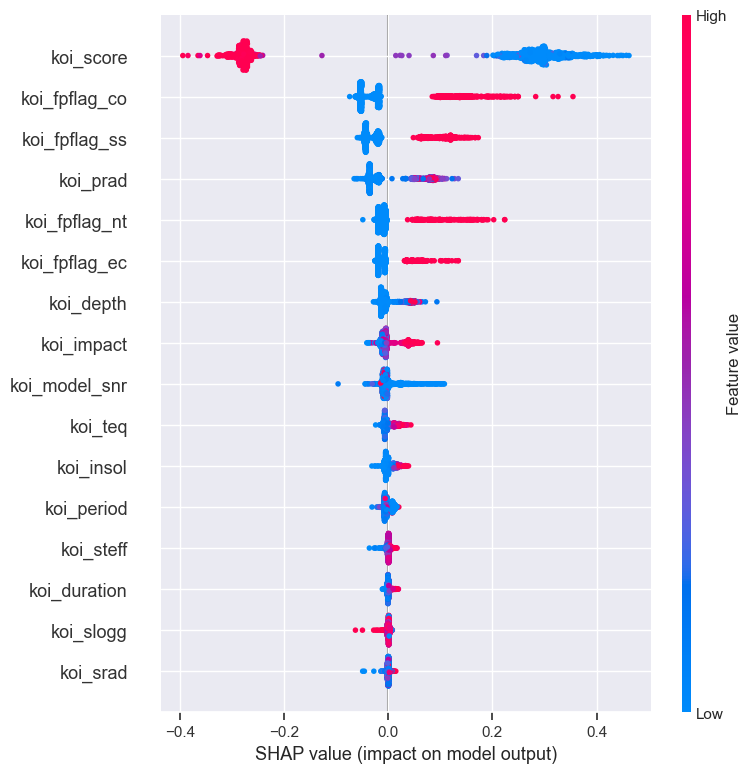

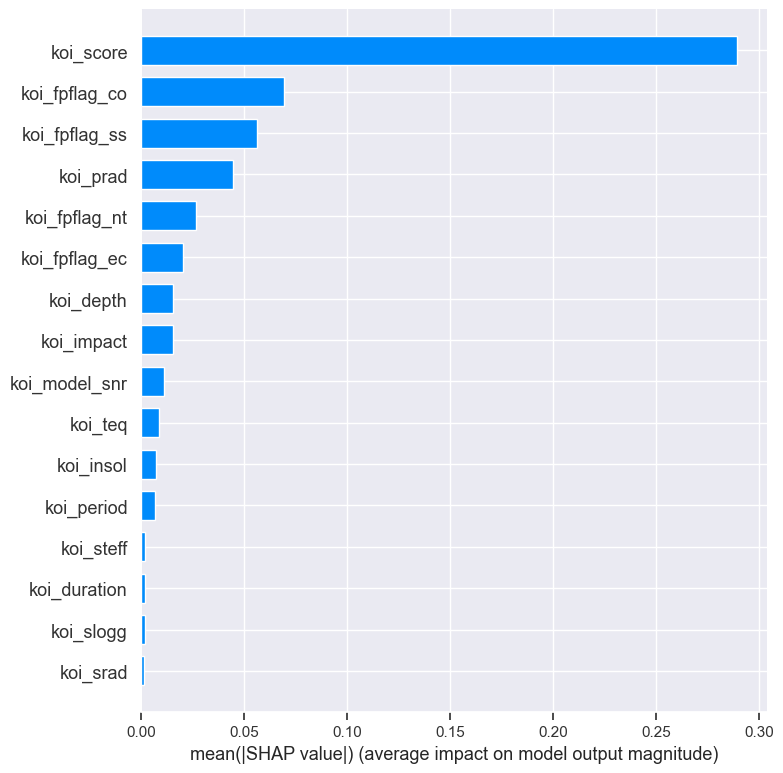

SHAP plots saved to outputs folder


In [22]:
explainer_rf = shap.TreeExplainer(results['Random Forest']['model'])
shap_values_rf = explainer_rf.shap_values(X_test_imp)

if isinstance(shap_values_rf, list):
    # Older SHAP versions: list of arrays, one per class
    shap_vals_plot = shap_values_rf[1]
elif shap_values_rf.ndim == 3:
    # Newer SHAP versions (like yours): single 3D array (samples, features, classes)
    shap_vals_plot = shap_values_rf[:, :, 1]
else:
    # Already 2D
    shap_vals_plot = shap_values_rf

print("Final shape used for plotting:", shap_vals_plot.shape)  # should print (1241, 16)

# Summary plot (dot plot - shows direction + importance)
plt.figure(figsize=(10,8))
shap.summary_plot(shap_vals_plot, X_test_imp, feature_names=KEY_FEATURES, show=False)
plt.tight_layout()
plt.savefig(os.path.join(BASE, 'outputs', 'p6_shap_summary.png'), dpi=150, bbox_inches='tight')
plt.show()
plt.close()

# Bar plot (mean absolute importance - cleaner for paper)
plt.figure(figsize=(9,6))
shap.summary_plot(shap_vals_plot, X_test_imp, feature_names=KEY_FEATURES, plot_type='bar', show=False)
plt.tight_layout()
plt.savefig(os.path.join(BASE, 'outputs', 'p6_shap_importance_bar.png'), dpi=150, bbox_inches='tight')
plt.show()
plt.close()

print("SHAP plots saved to outputs folder")

SHAP excluding koi_score

Physical-only model (no koi_score):
 F1: 0.9912
 ROC-AUC: 0.9990
For comparison - full model (with koi_score):
 F1: 0.9943
 AUC: 0.9989

Final shape used for plotting: (1241, 15)


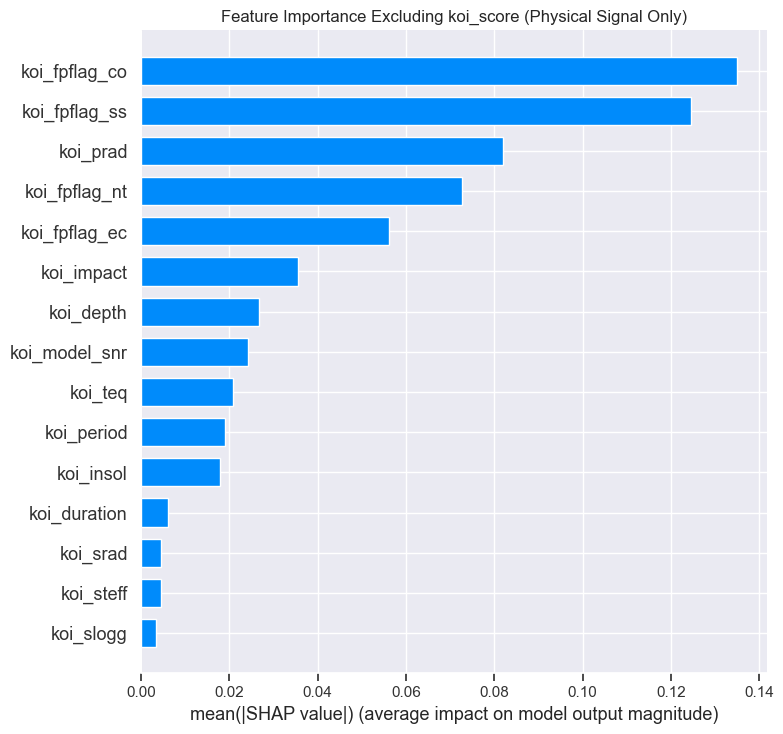

In [23]:
PHYSICAL_FEATURES = [f for f in KEY_FEATURES if f != 'koi_score']

X_train_physical = pd.DataFrame(X_train_bal, columns=KEY_FEATURES)[PHYSICAL_FEATURES]
X_test_physical = pd.DataFrame(X_test_imp, columns=KEY_FEATURES)[PHYSICAL_FEATURES]

rf_physical = RandomForestClassifier(
    n_estimators = 200, min_samples_split=5, random_state=42, n_jobs=-1
)
rf_physical.fit(X_train_physical, y_train_bal)

y_pred_physical = rf_physical.predict(X_test_physical)
y_prob_physical = rf_physical.predict_proba(X_test_physical)[:, 1]

f1_physical = f1_score(y_test, y_pred_physical)
auc_physical = roc_auc_score(y_test, y_prob_physical)

print(f"Physical-only model (no koi_score):")
print(f" F1: {f1_physical:.4f}")
print(f" ROC-AUC: {auc_physical:.4f}")
print(f"For comparison - full model (with koi_score):")
print(f" F1: {results['Random Forest']['f1']:.4f}")
print(f" AUC: {results['Random Forest']['auc']:.4f}")

explainer_physical = shap.TreeExplainer(rf_physical)
shap_values_physical = explainer_physical.shap_values(X_test_physical)

if isinstance(shap_values_physical, list):
    shap_values_physical_plot = shap_values_physical[1]
elif shap_values_physical.ndim == 3:
    shap_values_physical_plot = shap_values_physical[:, :, 1]
else:
    shap_values_physical_plot = shap_values_physical

print("\nFinal shape used for plotting:", shap_values_physical_plot.shape)

plt.figure(figsize=(9,6))
shap.summary_plot(shap_values_physical_plot, X_test_physical, plot_type='bar', show=False)
plt.title('Feature Importance Excluding koi_score (Physical Signal Only)')
plt.tight_layout()
plt.savefig(os.path.join(BASE, 'outputs', 'p6_shap_physical_only.png'), dpi=150, bbox_inches = 'tight')
plt.show()
plt.close()

Misclassification Analysis

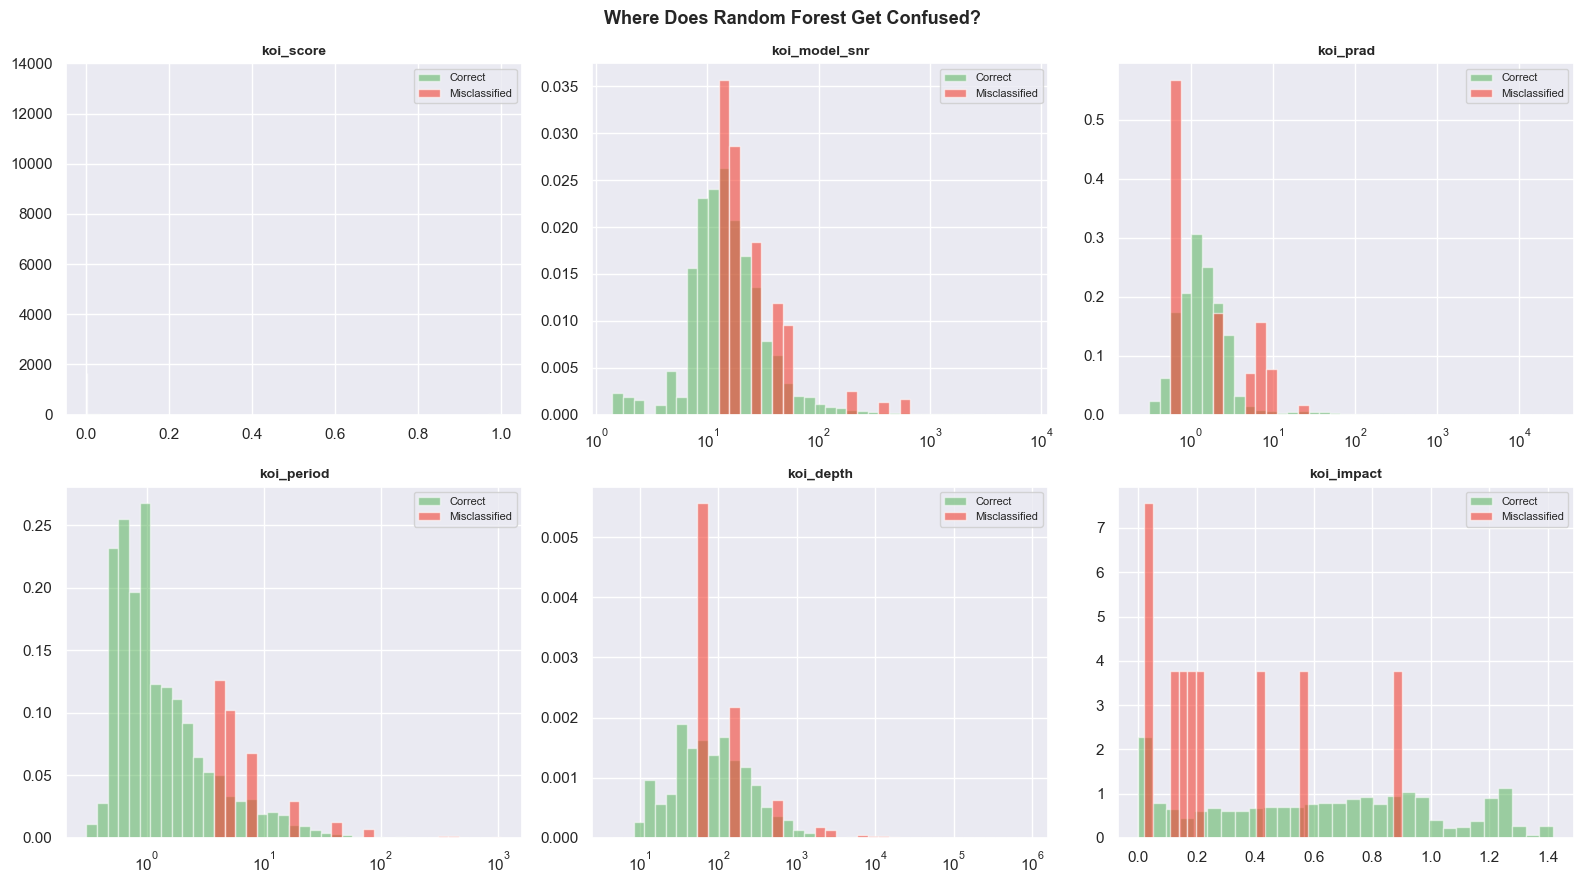

Misclassification plot saved to outputs/ folder (log-scale corrected)


In [24]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
compare_features = ['koi_score', 'koi_model_snr', 'koi_prad', 'koi_period', 'koi_depth', 'koi_impact']

# Features that need log-scale treatment due to extreme outliers/skew
log_scale_features = ['koi_model_snr', 'koi_prad', 'koi_period', 'koi_depth']

for i, feat in enumerate(compare_features):
    ax = axes[i]

    if feat in log_scale_features:
        # Use log-scale bins, drop zero/negative values (log undefined there)
        correct_vals = correctly_classified[feat][correctly_classified[feat] > 0]
        mis_vals = misclassified[feat][misclassified[feat] > 0]

        combined = pd.concat([correct_vals, mis_vals])
        bins = np.logspace(np.log10(combined.min()), np.log10(combined.max()), 40)

        ax.hist(correct_vals, bins=bins, alpha=0.5, label='Correct', color='#4CAF50', density=True)
        ax.hist(mis_vals, bins=bins, alpha=0.6, label='Misclassified', color='#F44336', density=True)
        ax.set_xscale('log')
    else:
        # koi_score, koi_impact - linear scale is fine, just clip to 99th percentile
        combined = pd.concat([correctly_classified[feat], misclassified[feat]])
        upper = combined.quantile(0.99)

        ax.hist(correctly_classified[feat].clip(upper=upper), bins=30, alpha=0.5,
                label='Correct', color='#4CAF50', density=True)
        ax.hist(misclassified[feat].clip(upper=upper), bins=30, alpha=0.6,
                label='Misclassified', color='#F44336', density=True)

    ax.set_title(feat, fontsize=10, fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('Where Does Random Forest Get Confused?', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(BASE, 'outputs', 'p6_misclassification_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()
plt.close()

print("Misclassification plot saved to outputs/ folder (log-scale corrected)")

In [25]:
print("koi_score - Correctly classified stats:")
print(correctly_classified['koi_score'].describe())
print("\nkoi_score - Misclassified stats:")
print(misclassified['koi_score'].describe())
print("\nUnique values sample (correct):", correctly_classified['koi_score'].unique()[:20])

koi_score - Correctly classified stats:
count    1232.000000
mean        0.365598
std         0.467312
min         0.000000
25%         0.000000
50%         0.000000
75%         0.995000
max         1.000000
Name: koi_score, dtype: float64

koi_score - Misclassified stats:
count    9.000000
mean     0.000222
std      0.000667
min      0.000000
25%      0.000000
50%      0.000000
75%      0.000000
max      0.002000
Name: koi_score, dtype: float64

Unique values sample (correct): [0.    0.814 1.    0.99  0.975 0.999 0.998 0.985 0.046 0.04  0.989 0.006
 0.996 0.03  0.878 0.979 0.761 0.113 0.993 0.216]


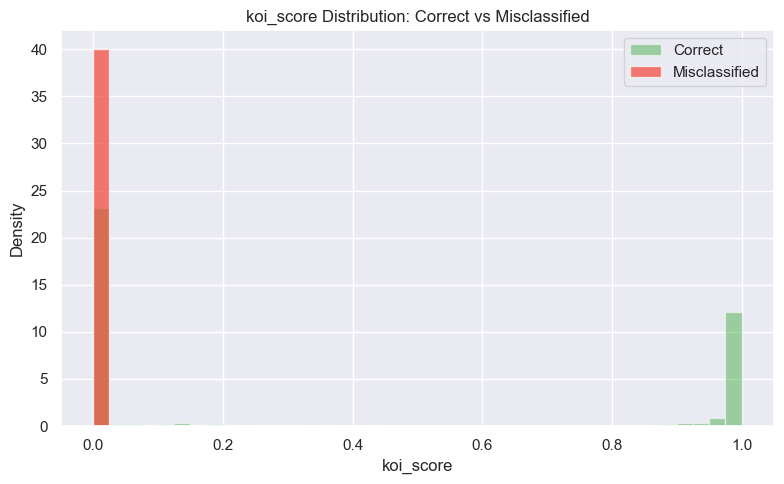

All 9 misclassified rows, full detail:
      koi_score  koi_model_snr  koi_prad   koi_period  koi_depth  koi_impact  \
2579      0.000          577.1      7.74    19.270826     6660.5       0.169   
7323      0.000           14.2      0.68     3.875943       58.6       0.025   
2927      0.000          544.2      9.27  1071.232624    19046.0       0.216   
4990      0.000          181.0      7.23   440.784376     2579.0       0.424   
2775      0.000          355.0     10.89   331.597273     8322.1       0.020   
3085      0.000           25.8      2.22    39.603400      572.7       0.166   
5062      0.000           56.4     22.27     5.546083     2211.0       0.902   
5671      0.000           38.6      6.28    76.377855    11004.0       0.577   
4591      0.002           16.3      5.05     7.319453      166.8       0.112   

     true_label predicted_label  
2579  CONFIRMED  FALSE POSITIVE  
7323  CONFIRMED  FALSE POSITIVE  
2927  CONFIRMED  FALSE POSITIVE  
4990  CONFIRMED  FALSE P

In [26]:
# Dedicated koi_score plot - separate from the grid, since it's bimodal and behaves differently
plt.figure(figsize=(8, 5))
bins = np.linspace(0, 1, 41)
plt.hist(correctly_classified['koi_score'], bins=bins, alpha=0.5, label='Correct', color='#4CAF50', density=True)
plt.hist(misclassified['koi_score'], bins=bins, alpha=0.7, label='Misclassified', color='#F44336', density=True)
plt.xlabel('koi_score')
plt.ylabel('Density')
plt.title('koi_score Distribution: Correct vs Misclassified')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(BASE, 'outputs', 'p6_koi_score_misclassified.png'), dpi=150, bbox_inches='tight')
plt.show()
plt.close()

# The real prize: look at all 9 misclassified rows directly, since there are so few
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
print("All 9 misclassified rows, full detail:")
print(misclassified[['koi_score', 'koi_model_snr', 'koi_prad', 'koi_period',
                       'koi_depth', 'koi_impact', 'true_label', 'predicted_label']])